In [2]:
pip install matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\koush\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [4]:
df = pd.read_csv('used_cars_2015_2024.csv')
df.head()

,Brand,Model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,Price
0,Maruti Suzuki,Swift,2017,7,83500.0,Manual,Second,Diesel,Nov-24,Maruti Suzuki Swift 2017 Diesel Good Condition,565000.0
1,Maruti Suzuki,Baleno,2019,5,45000.0,Automatic,First,Petrol,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol",685000.0
2,BMW,5 Series,2019,5,25000.0,Automatic,Second,Diesel,Nov-24,"BMW 5 Series 3.0 530D M Sport, 2019, Diesel",5950000.0
3,Maruti Suzuki,maruti-suzuki-dzire,2020,4,33759.0,Manual,Second,Petrol,Nov-24,"Maruti Suzuki Dzire 1.2 VXI, 2020, Petrol",622000.0
4,Ford,Ecosport,2017,7,69713.0,Manual,Second,Petrol,Nov-24,"Ford Ecosport 1.5 Ti VCT MT Titanium BE, 2017,...",649000.0


 Price Distribution

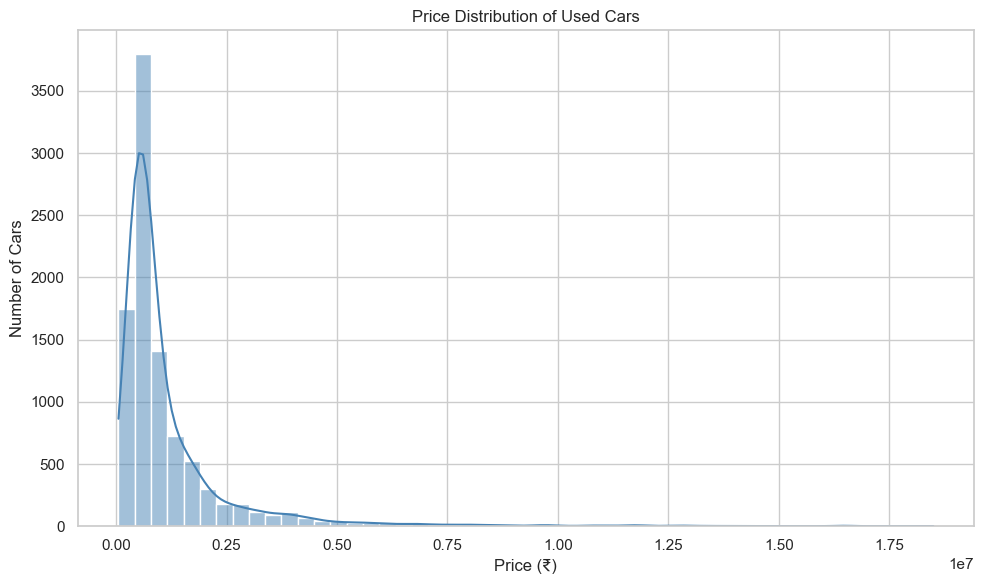

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], bins=50, kde=True, color='steelblue')
plt.title('Price Distribution of Used Cars')
plt.xlabel('Price (₹)')
plt.ylabel('Number of Cars')
plt.tight_layout()
plt.show()

Brand-wise Car Count (Top 10)

C:\Users\koush\AppData\Local\Temp\ipykernel_2584\678835689.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.values, y=top_brands.index, palette='Blues_r')


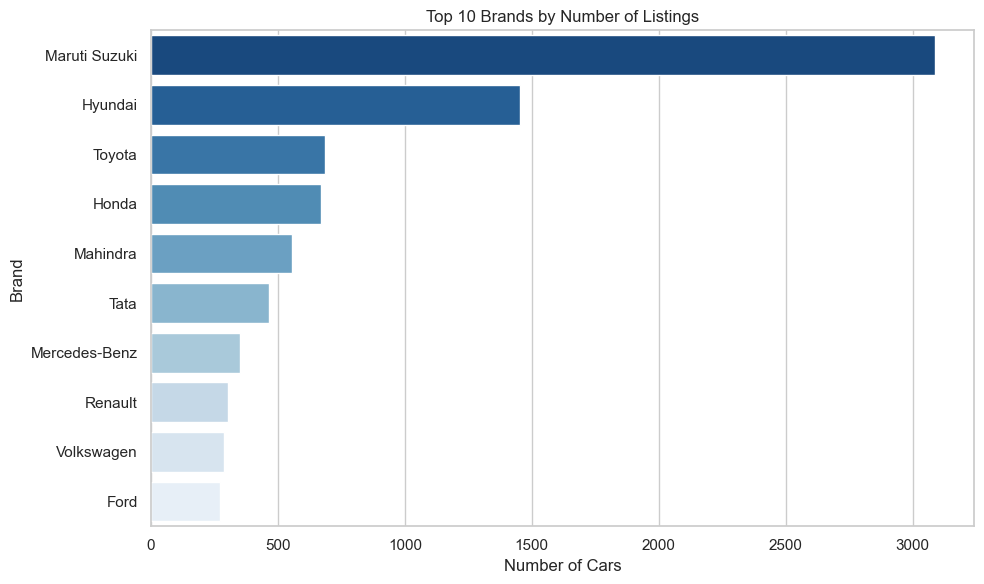

In [7]:
plt.figure(figsize=(10, 6))
top_brands = df['Brand'].value_counts().head(10)
sns.barplot(x=top_brands.values, y=top_brands.index, palette='Blues_r')
plt.title('Top 10 Brands by Number of Listings')
plt.xlabel('Number of Cars')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()


KM Driven vs Price

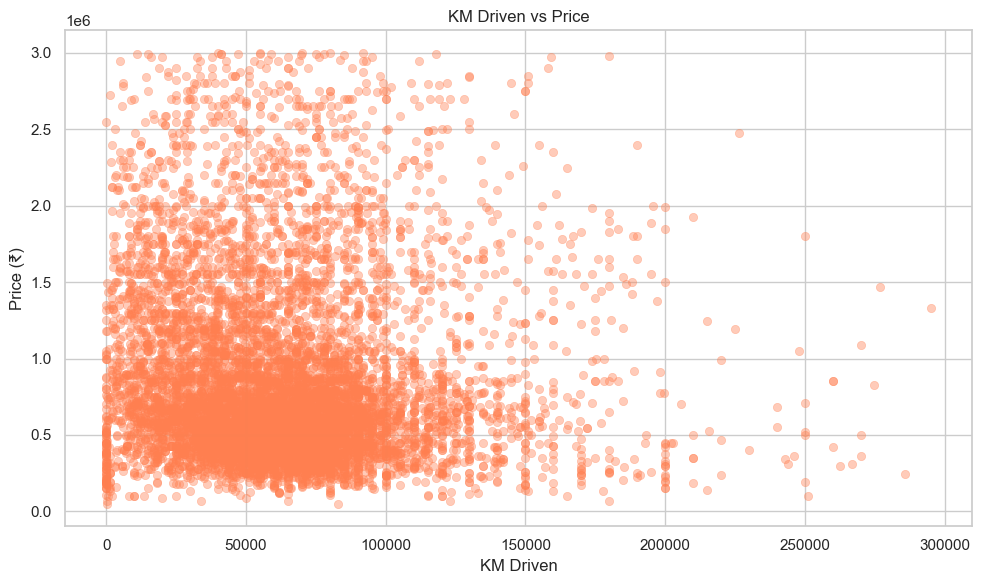

In [8]:
plt.figure(figsize=(10, 6))
df_clean = df[(df['Price'] < 3000000) & (df['kmDriven'] < 300000)]
sns.scatterplot(data=df_clean, x='kmDriven', y='Price',
                alpha=0.4, color='coral', edgecolor=None)
plt.title('KM Driven vs Price')
plt.xlabel('KM Driven')
plt.ylabel('Price (₹)')
plt.tight_layout()
plt.show()

Year-wise Listings

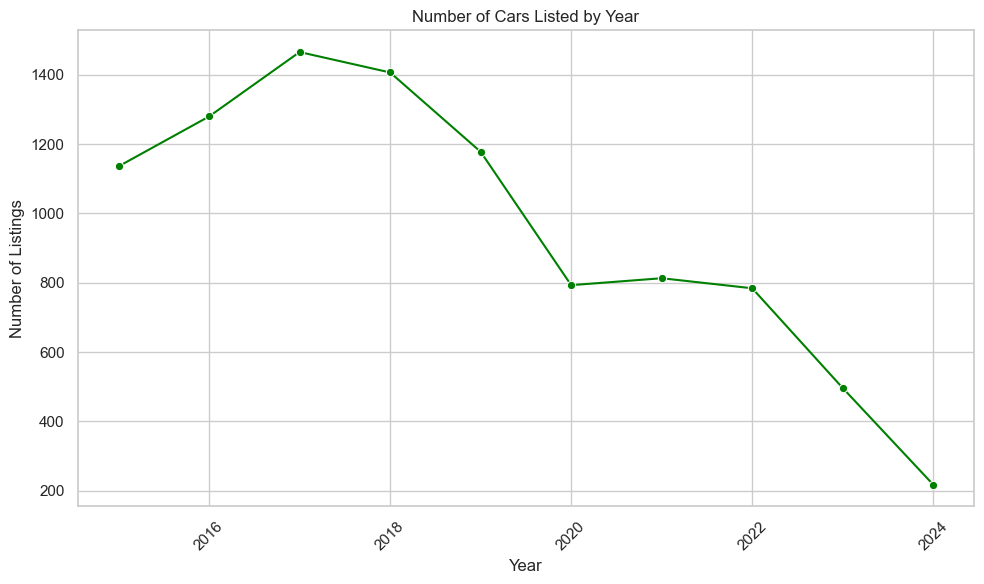

In [9]:
plt.figure(figsize=(10, 6))
year_counts = df['Year'].value_counts().sort_index()
sns.lineplot(x=year_counts.index, y=year_counts.values,
             marker='o', color='green')
plt.title('Number of Cars Listed by Year')
plt.xlabel('Year')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

 Owner Type Analysis

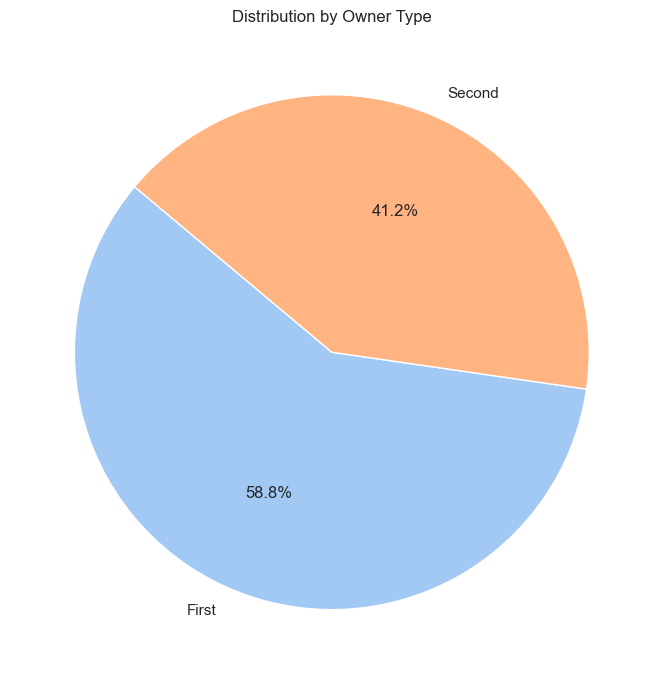

In [10]:
plt.figure(figsize=(7, 7))
owner_counts = df['Owner'].value_counts()
colors = sns.color_palette('pastel')
plt.pie(owner_counts.values, labels=owner_counts.index,
        autopct='%1.1f%%', colors=colors, startangle=140)
plt.title('Distribution by Owner Type')
plt.tight_layout()
plt.show()

Fuel Type Breakdown

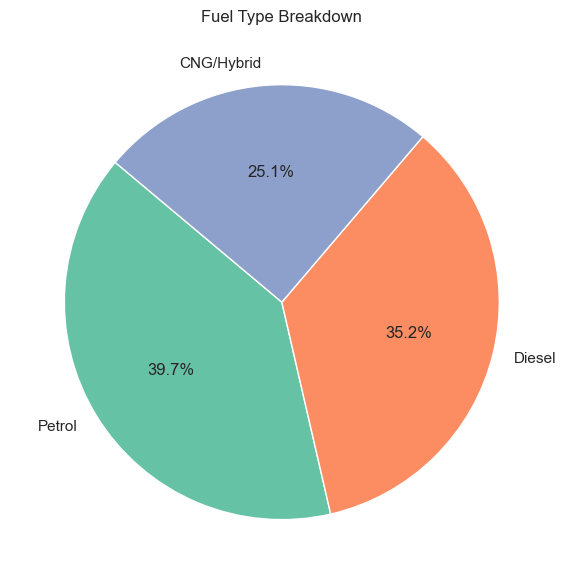

In [11]:
plt.figure(figsize=(8, 6))
fuel_counts = df['FuelType'].value_counts()
colors = sns.color_palette('Set2')
plt.pie(fuel_counts.values, labels=fuel_counts.index,
        autopct='%1.1f%%', colors=colors, startangle=140)
plt.title('Fuel Type Breakdown')
plt.tight_layout()
plt.show()

Transmission Split

C:\Users\koush\AppData\Local\Temp\ipykernel_2584\3203285747.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=trans_counts.index, y=trans_counts.values,


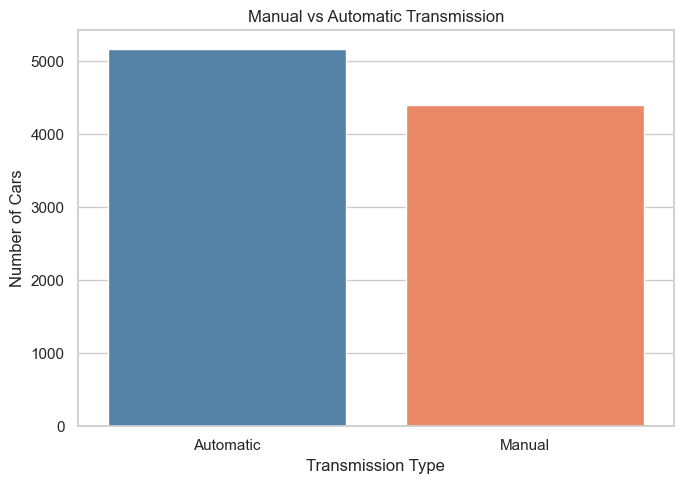

In [13]:
plt.figure(figsize=(7, 5))
trans_counts = df['Transmission'].value_counts()
sns.barplot(x=trans_counts.index, y=trans_counts.values,
            palette=['steelblue', 'coral'])
plt.title('Manual vs Automatic Transmission')
plt.xlabel('Transmission Type')
plt.ylabel('Number of Cars')
plt.tight_layout()
plt.show()

Average Price by Brand (Top 10)

C:\Users\koush\AppData\Local\Temp\ipykernel_2584\51569012.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price.values, y=avg_price.index, palette='Oranges_r')


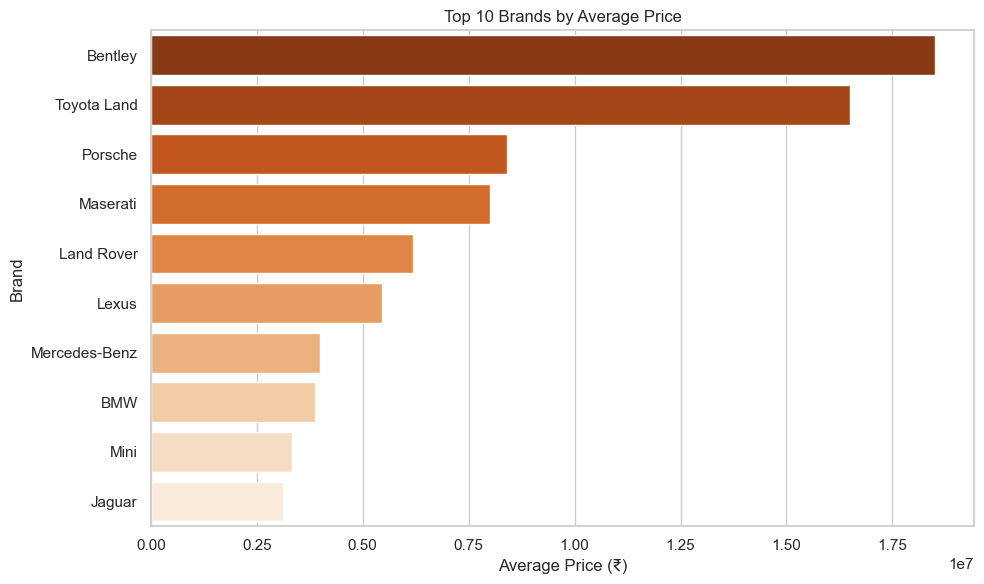

In [14]:
plt.figure(figsize=(10, 6))
avg_price = df.groupby('Brand')['Price'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=avg_price.values, y=avg_price.index, palette='Oranges_r')
plt.title('Top 10 Brands by Average Price')
plt.xlabel('Average Price (₹)')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()

 Price vs Age of Car

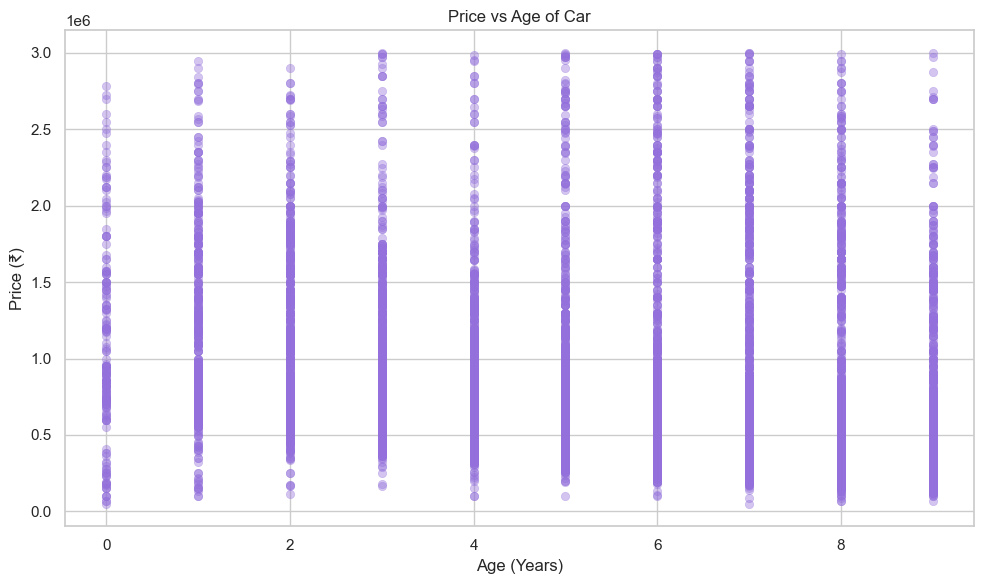

In [15]:
plt.figure(figsize=(10, 6))
df_clean2 = df[df['Price'] < 3000000]
sns.scatterplot(data=df_clean2, x='Age', y='Price',
                alpha=0.4, color='mediumpurple', edgecolor=None)
plt.title('Price vs Age of Car')
plt.xlabel('Age (Years)')
plt.ylabel('Price (₹)')
plt.tight_layout()
plt.show()

Correlation Heatmap

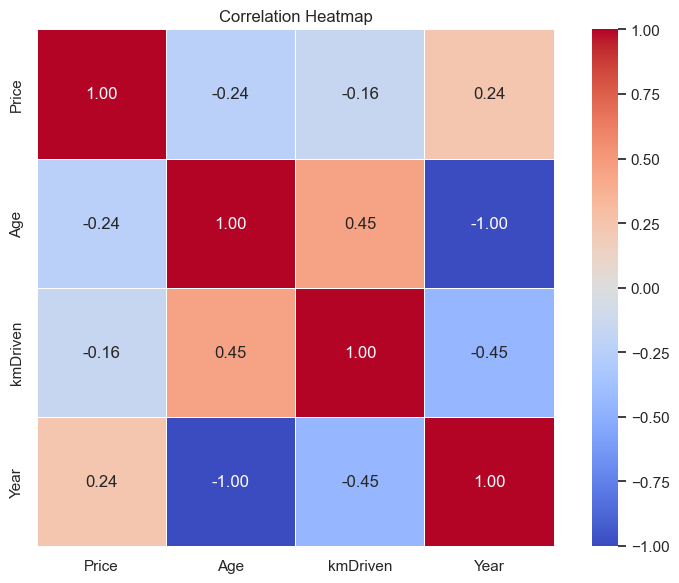

In [16]:
plt.figure(figsize=(8, 6))
corr = df[['Price', 'Age', 'kmDriven', 'Year']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()